# Práctica – Embeddings Semánticos con Sentence Transformers
## UNR · TUIA · Procesamiento de Lenguaje Natural – Unidad 2

En esta práctica trabajamos con **modelos de embeddings semánticos** densos
usando el modelo liviano `intfloat/multilingual-e5-small` (384 dimensiones, ~118 MB).

A diferencia de los métodos frecuentistas (TF-IDF, Count), estos embeddings
capturan el **significado semántico** del texto: dos frases con palabras
completamente distintas pero significados similares tendrán vectores cercanos.

| Parte | Tema |
|-------|------|
| 1 | Carga del dataset y preparación |
| 2 | Vectorización y almacenamiento en ZIP |
| 3 | Importación de embeddings desde ZIP |
| 4 | Búsqueda semántica de libros |
| 5 | Sistema de recomendación "Libros similares" |
| 6 | Análisis de similitud entre géneros |
| 7 | Clustering con K-Means |
| 8 | Visualización 2D/3D del espacio semántico |
| 9 | Evaluación comparativa: E5 vs TF-IDF |

> **Flujo de trabajo**: La Parte 2 vectoriza todo el dataset y guarda los embeddings
> en un archivo ZIP. A partir de la Parte 3, se importan desde el ZIP para no
> tener que re-vectorizar cada vez que se abre el notebook.


---
## 📌 Notas de esta resolución

- **Cómo se ejecutó:** localmente, con el kernel `Python 3.12 (NLP TUIA)` y `U2/practicas/` como carpeta de trabajo, porque el notebook lee `data/...`.
- **La Parte 2 está protegida:** si `data/embeddings_e5_small.zip` ya existe, no se re-vectoriza (en Colab con GPU tardó 47 s; en CPU tarda bastante más) y se usan los embeddings del ZIP. El modelo se carga igual, porque los ejercicios 1 y 6 lo necesitan para codificar las consultas.
- Cada función `TODO` conserva su firma y su consigna; solo se completó el cuerpo, y se descomentaron las llamadas. Después de cada ejercicio hay una celda **📝 Interpretación**. Las celdas **Extra** no las pide la consigna.
- **Después de cargar el ZIP hay una celda Extra de limpieza** que repara texto mal codificado y quita libros repetidos (ver más abajo). Todos los ejercicios corren sobre los datos limpios.

### ⚠️ Errores de consigna y problemas de los datos

1. **Tamaño del modelo:** la intro dice "~118 MB" y la tabla dice "~450 MB en disco". Lo correcto es lo segundo: el modelo tiene ~118 **millones de parámetros**, y a 4 bytes cada uno da ~470 MB (lo que ocupa al bajarlo). El "118 MB" confunde parámetros con megabytes.
2. **"No hace falta tener sentence-transformers ni el modelo para resolver los ejercicios"** (Parte 3): vale para los ejercicios 2 a 5, pero no para el 1 y el 6, que codifican consultas nuevas con el modelo.
3. **`genero_principal` no es el género principal:** es el **primero en orden alfabético**, porque Lectulandia lista los géneros ordenados (se verificó en la práctica de vectorización frecuentista, en el 100 % de los libros). Una novela "Intriga - Novela" queda como Intriga, y una "Novela - Romántico", como Novela.
4. **Texto mal codificado (mojibake):** 1.871 libros (3,9 %) tienen cosas como "Hist√≥rico" en lugar de "Histórico". Eso crea **22 géneros fantasma**: los géneros distintos son 78, no los 100 que informa la Parte 1.
5. **Libros repetidos:** 683 libros aparecen dos veces (mismo título y autor), así que pueden ocupar dos lugares en un top-5.


In [1]:
# ── Instalaciones (ejecutar una vez) ──────────────────────────────────────
# !pip install sentence-transformers scikit-learn numpy pandas matplotlib seaborn

# ── Imports globales ──────────────────────────────────────────────────────
import re, os, zipfile, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score, adjusted_rand_score
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100


---
# Parte 1 – Carga y Preparación del Dataset

Usamos el dataset de **Lectulandia** (~62k libros). Filtramos los que tienen
sinopsis y limpiamos el texto para la vectorización.


In [2]:
# ── Cargar dataset ────────────────────────────────────────────────────────
df_raw = pd.read_csv("data/lectulandia_books.csv")
print(f"Dataset original: {len(df_raw):,} libros, {df_raw.columns.tolist()}")
print(f"Libros sin sinopsis: {df_raw['sinapsis'].isna().sum():,}")

# Filtrar libros con sinopsis
df = df_raw.dropna(subset=["sinapsis"]).copy()
df = df[df["sinapsis"].str.strip().str.len() > 50].reset_index(drop=True)
print(f"Libros con sinopsis válida (>50 chars): {len(df):,}")

# Limpieza básica del texto
def limpiar_texto(texto):
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df["sinopsis_clean"] = df["sinapsis"].apply(limpiar_texto)

# Extraer género principal (el primero de la lista)
df["genero_principal"] = df["generos"].fillna("Sin género").apply(
    lambda x: x.split(" - ")[0].strip()
)

# Estadísticas rápidas
print(f"\nLongitud promedio de sinopsis: {df['sinopsis_clean'].str.len().mean():.0f} caracteres")
print(f"Géneros únicos (principal): {df['genero_principal'].nunique()}")
print(f"\nTop 10 géneros:")
print(df["genero_principal"].value_counts().head(10).to_string())

Dataset original: 62,279 libros, ['url', 'titulo', 'autor', 'autor_url', 'sinapsis', 'imagen_url', 'generos']
Libros sin sinopsis: 14,449
Libros con sinopsis válida (>50 chars): 47,819



Longitud promedio de sinopsis: 929 caracteres
Géneros únicos (principal): 100

Top 10 géneros:
genero_principal
Novela               9363
Intriga              5304
Histórico            3604
Drama                3305
Ensayo               2715
Aventuras            2506
Ciencia ficción      2440
Fantástico           2340
Ciencias sociales    2197
Crónica              2083


---
# Parte 2 – Vectorización con `intfloat/multilingual-e5-small` y Guardado en ZIP

## Sobre el modelo

`intfloat/multilingual-e5-small` es un modelo de embeddings multilingüe entrenado
con la técnica E5 (*EmbEddings from tExtual data with Text-to-text format*).

| Propiedad | Valor |
|-----------|-------|
| Dimensiones | 384 |
| Parámetros | ~118M |
| Idiomas | 100+ (incluye español) |
| Tamaño en disco | ~450 MB |
| Velocidad | Rápido en CPU |

**Importante**: E5 usa un prefijo para indicar el tipo de texto:
- `"query: "` para consultas de búsqueda
- `"passage: "` para documentos/pasajes a indexar

Esto mejora la calidad de los embeddings significativamente.

> **Esta celda tarda ~5-10 minutos en CPU para el dataset completo (~48k libros).** Los embeddings se guardan en un ZIP
> para no tener que repetir este paso. Si ya tenés el ZIP, saltá a la Parte 3.


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# CELDA DE VECTORIZACIÓN — Ejecutar UNA vez, luego usar el ZIP
# ══════════════════════════════════════════════════════════════════════════
from sentence_transformers import SentenceTransformer
import time

MODEL_NAME = "intfloat/multilingual-e5-small"
ZIP_PATH = "data/embeddings_e5_small.zip"

# El modelo se carga siempre: los ejercicios 1 y 6 lo necesitan para codificar las consultas
model = SentenceTransformer(MODEL_NAME)

# Si el ZIP ya existe (generado antes o bajado de Drive), no se re-vectoriza:
# en CPU, las ~48k sinopsis tardan mucho más que los 47 s que tardó en Colab con GPU
VECTORIZAR = not os.path.exists(ZIP_PATH)

if VECTORIZAR:
    # Preparar textos con el prefijo "passage:" que usa E5
    textos_para_encode = ["passage: " + t for t in df["sinopsis_clean"].tolist()]

    print(f"Vectorizando {len(textos_para_encode):,} sinopsis con {MODEL_NAME}...")
    print(f"Esto puede tardar ~5-10 minutos en CPU...")

    t0 = time.time()
    embeddings = model.encode(
        textos_para_encode,
        show_progress_bar=True,
        batch_size=64,
        normalize_embeddings=True
    )
    elapsed = time.time() - t0

    print(f"\nVectorización completada en {elapsed:.1f}s")
    print(f"Shape de embeddings: {embeddings.shape}")
    print(f"Tipo: {embeddings.dtype}")
    print(f"Norma L2 promedio: {np.linalg.norm(embeddings, axis=1).mean():.4f}")
else:
    print(f"Ya existe {ZIP_PATH}: no se re-vectoriza (los embeddings se cargan en la Parte 3).")
    print(f"Modelo {MODEL_NAME} cargado para codificar consultas.")

C:\Users\jcalabozo\TUIA\tuia-nlp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:  21%|██        | 41/199 [00:00<00:00, 403.56it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1694.54it/s]

Ya existe data/embeddings_e5_small.zip: no se re-vectoriza (los embeddings se cargan en la Parte 3).
Modelo intfloat/multilingual-e5-small cargado para codificar consultas.


### Guardar embeddings y metadata en ZIP

Guardamos en un archivo ZIP:
- `embeddings.npy` — la matriz numpy de embeddings (shape: N x 384)
- `metadata.csv` — información de cada libro (título, autor, género, sinopsis)
- `config.json` — configuración del modelo y parámetros usados

Así cualquier celda posterior puede importar todo sin necesidad de re-vectorizar.


In [4]:
# ══════════════════════════════════════════════════════════════════════════
# GUARDAR EMBEDDINGS EN ZIP
# ══════════════════════════════════════════════════════════════════════════
import json

ZIP_PATH = "data/embeddings_e5_small.zip"

# Solo se guarda si se acaba de vectorizar; si no, se deja el ZIP como está
if VECTORIZAR:
    # Preparar metadata
    df_meta = df[["titulo", "autor", "sinopsis_clean", "genero_principal", "generos"]].copy()
    df_meta.columns = ["titulo", "autor", "sinopsis", "genero_principal", "generos"]

    # Configuración
    config = {
        "model_name": MODEL_NAME,
        "embedding_dim": int(embeddings.shape[1]),
        "n_documents": int(embeddings.shape[0]),
        "normalized": True,
        "prefix_used": "passage: ",
        "dtype": str(embeddings.dtype),
    }

    # Guardar en ZIP
    with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
        # Embeddings como .npy
        buf = io.BytesIO()
        np.save(buf, embeddings)
        zf.writestr("embeddings.npy", buf.getvalue())

        # Metadata como CSV
        csv_buf = io.StringIO()
        df_meta.to_csv(csv_buf, index=False)
        zf.writestr("metadata.csv", csv_buf.getvalue())

        # Config como JSON
        zf.writestr("config.json", json.dumps(config, indent=2, ensure_ascii=False))
else:
    print("No se re-vectorizó: se usa el ZIP existente.")

file_size_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)
print(f"Archivo: {ZIP_PATH}")
print(f"   Tamaño: {file_size_mb:.1f} MB")
print(f"   Contenido:")
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    for info in zf.infolist():
        print(f"     - {info.filename}: {info.file_size / 1024:.1f} KB")

No se re-vectorizó: se usa el ZIP existente.
Archivo: data/embeddings_e5_small.zip
   Tamaño: 81.8 MB
   Contenido:
     - embeddings.npy: 71728.6 KB
     - metadata.csv: 47969.9 KB
     - config.json: 0.2 KB


---
# Parte 3 – Importar Embeddings desde ZIP

> **A partir de acá, todas las celdas usan los embeddings pre-calculados.**
> No hace falta tener `sentence-transformers` instalado ni el modelo descargado
> para resolver los ejercicios — solo el archivo ZIP.

Si no generaste el ZIP, podés descargarlo desde [Google Drive](https://drive.google.com/file/d/1SxsCy9airq_1OaNKFVUu_SB7HGSTe_gk/view?usp=sharing) y colocarlo en `data/embeddings_e5_small.zip`.

Ejecutá la siguiente celda para cargar embeddings y metadata.

In [5]:
# ══════════════════════════════════════════════════════════════════════════
# IMPORTAR EMBEDDINGS DESDE ZIP — Ejecutar siempre
# ══════════════════════════════════════════════════════════════════════════
import zipfile, io, json
import numpy as np
import pandas as pd

ZIP_PATH = "data/embeddings_e5_small.zip"

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    # Cargar embeddings
    with zf.open("embeddings.npy") as f:
        embeddings = np.load(io.BytesIO(f.read()))

    # Cargar metadata
    with zf.open("metadata.csv") as f:
        df_libros = pd.read_csv(io.BytesIO(f.read()))

    # Cargar config
    with zf.open("config.json") as f:
        config = json.loads(f.read())

print(f"Embeddings cargados desde ZIP")
print(f"   Modelo: {config['model_name']}")
print(f"   Documentos: {embeddings.shape[0]:,}")
print(f"   Dimensiones: {embeddings.shape[1]}")
print(f"   Normalizados: {config['normalized']}")
print(f"\nPrimeras filas del dataset:")
df_libros.head()

Embeddings cargados desde ZIP
   Modelo: intfloat/multilingual-e5-small
   Documentos: 47,819
   Dimensiones: 384
   Normalizados: True

Primeras filas del dataset:


,titulo,autor,sinopsis,genero_principal,generos
0,Tierra feroz,Jota Quijorna,La oscuridad de un alma herida es el hogar de ...,Intriga,Intriga - Novela
1,Tehanu,Ursula K. Le Guin,"El mal medra, y la magia se ha pervertido. En ...",Fantástico,Fantástico - Novela
2,El niño del taxi,Sylvain Prudhomme,"Durante el funeral de su abuelo, Simon descubr...",Histórico,Histórico - Novela
3,James Bond 007: El juego de rol,Gerard Christopher Klug,ATRÉVETE A VIVIR EN EL FASCINANTE MUNDO DE JAM...,Juegos,Juegos - Manuales y cursos - Referencia
4,El retorno del cuervo,Alissa Brontë,"Tras varios años alejado del que fue su hogar,...",Histórico,Histórico - Novela - Romántico


In [6]:
# ── Extra (no pedido): limpieza de datos antes de los ejercicios ─────────────
# 1) Texto mal codificado ("mojibake"): unos 1.900 libros dicen "Hist√≥rico" en vez de
#    "Histórico". Es texto UTF-8 que en algún paso se leyó como si fuera Mac Roman
#    (el tema de encodings de la Unidad 1). Se repara volviendo a los bytes que
#    produjo esa lectura equivocada y decodificándolos, esta vez, como UTF-8.
def reparar_mojibake(texto):
    if not isinstance(texto, str) or "√" not in texto:
        return texto
    try:
        return texto.encode("mac_roman").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return texto  # si no se puede reparar, queda como estaba

print(f"Ejemplo: {reparar_mojibake('Hist√≥rico')!r}")
print(f"Géneros distintos antes de reparar:  {df_libros['genero_principal'].nunique()}")
for col in ["titulo", "autor", "sinopsis", "genero_principal", "generos"]:
    df_libros[col] = df_libros[col].apply(reparar_mojibake)
print(f"Géneros distintos después de reparar: {df_libros['genero_principal'].nunique()}")

# 2) Libros repetidos (mismo título y autor): saldrían dos veces en las búsquedas.
#    Se quita la fila y también su embedding, para que sigan alineados fila a fila.
repetido = df_libros.duplicated(subset=["titulo", "autor"]).to_numpy()
embeddings = embeddings[~repetido]
df_libros = df_libros[~repetido].reset_index(drop=True)
print(f"\nLibros repetidos quitados: {repetido.sum()} → quedan {len(df_libros):,} libros")


Ejemplo: 'Histórico'
Géneros distintos antes de reparar:  100
Géneros distintos después de reparar: 78

Libros repetidos quitados: 683 → quedan 47,136 libros


#### 📝 Interpretación — Extra: limpieza

- **Mojibake:** lo grave no es la estética, sino que **partía géneros en dos**: "Histórico" y "Hist√≥rico" contaban como géneros distintos. Al repararlo, los géneros distintos bajan de **100 a 78**. Sin esto, los ejercicios 3 a 5 trabajan con géneros incompletos.
- **Por qué funciona la reparación** (encodings, Unidad 1): en UTF-8, la "ó" son 2 bytes (`C3 B3`). Al leerlos como Mac Roman, cada byte se volvió un carácter: `√` y `≥`. Codificar de nuevo con Mac Roman recupera esos 2 bytes, y decodificarlos como UTF-8 devuelve la "ó".
- **Duplicados:** se quitan 683 libros repetidos, junto con su embedding, para que `df_libros` y `embeddings` sigan alineados fila a fila.
- Los embeddings de los libros que tenían mojibake se calcularon sobre el texto roto. No se recalculan acá, porque haría falta re-vectorizar. Son el 3,9 % del corpus y E5 tolera bastante esos caracteres raros, así que el efecto debería ser chico.


---
# Parte 4 – Búsqueda Semántica de Libros

Los embeddings semánticos permiten buscar libros por **significado**, no por
palabras clave exactas.

### Ejercicio 1 – Búsqueda Semántica por Texto

Implementá `buscar_libros` que reciba una query en lenguaje natural y
devuelva los N libros más relevantes usando similitud coseno.

**Recordá** que E5 usa el prefijo `"query: "` para las consultas.

In [7]:
def buscar_libros(query, embeddings, df_libros, model, n=5):
    """
    TODO:
    1. Codificar la query con model.encode() usando prefijo "query: "
    2. Calcular cosine_similarity contra todos los embeddings
    3. Retornar los top-N como DataFrame (titulo, autor, genero_principal, score)
    """
    # 1. Codificar la query con el prefijo de E5. normalize_embeddings=True deja el
    #    vector con norma 1, igual que los embeddings guardados en el ZIP
    q = model.encode(["query: " + query], normalize_embeddings=True)

    # 2. Similitud coseno contra todos los libros: un score por libro
    scores = cosine_similarity(q, embeddings)[0]

    # 3. Los n scores más altos (argsort ordena de menor a mayor; [::-1] lo invierte)
    top = np.argsort(scores)[::-1][:n]
    resultado = df_libros.iloc[top][["titulo", "autor", "genero_principal"]].copy()
    resultado["score"] = scores[top].round(3)
    return resultado


queries_test = [
    "historia de amor en tiempos de guerra",
    "aventuras de fantasía con dragones y magia",
    "divulgación científica sobre el universo",
]

for q in queries_test:
    print(f"\n «{q}»")
    print(buscar_libros(q, embeddings, df_libros, model).to_string(index=False))


 «historia de amor en tiempos de guerra»


                           titulo         autor genero_principal  score
             La mujer del Coronel   Rosa Liksom            Drama  0.886
                        El auriga  Mary Renault            Drama  0.880
                   Tiempo que fue  Ian McDonald  Ciencia ficción  0.879
La guardiana de recuerdos de Kyiv Erin Litteken            Drama  0.878
                   Tinta y ceniza   Andrea Tomé        Histórico  0.878

 «aventuras de fantasía con dragones y magia»


                                titulo          autor genero_principal  score
                    La pluma del grifo Cornelia Funke       Fantástico  0.885
    Los mejores relatos de fantasía II    Alan Garner       Fantástico  0.871
                     El ojo del dragón    Dave Morris        Aventuras  0.870
The Dragon Nindenn-Ka-Yh: Renacimiento  David Cabrera       Fantástico  0.869
              El libro de los dragones Varios Autores        Aventuras  0.869

 «divulgación científica sobre el universo»


                         titulo          autor   genero_principal  score
 Guía de la Tierra y el espacio   Isaac Asimov Ciencias naturales  0.890
El universo en una taza de café  Jordi Pereyra Ciencias naturales  0.881
              Universos ocultos   Lisa Randall   Ciencias exactas  0.877
        El universo en una caja Andrew Pontzen         Astronomía  0.875
       El planeta que no estaba   Isaac Asimov Ciencias naturales  0.873


#### 📝 Interpretación — Ejercicio 1

- Los resultados tienen **sentido semántico**: para "amor en tiempos de guerra" aparecen dramas e históricos ambientados en guerras; para "dragones y magia", fantasía; para "el universo", divulgación de Asimov y de Lisa Randall, entre otros.
- **Ojo con los scores:** todos están entre **0,87 y 0,89**. Es típico de E5: sus similitudes coseno se concentran en un rango alto y angosto (casi nunca bajan de ~0,7). Por eso **importa el ranking, no el valor absoluto**: 0,88 no quiere decir "88 % parecido". Es el mismo fenómeno que obliga a centrar en el Ejercicio 3.
- **Por qué el prefijo `query: `:** E5 se entrenó con pares de consulta corta y pasaje largo. El prefijo le indica qué papel cumple cada texto; sin él, la búsqueda empeora.


---
# Parte 5 – Libros Similares (sin modelo)

Dado un libro del dataset, encontrar los más parecidos usando solo los
embeddings precalculados. **No requiere cargar el modelo.**

### Ejercicio 2 – Encontrar Libros Similares

Implementá `libros_similares` que dado el índice de un libro retorne
los N más parecidos (excluyéndose a sí mismo).

In [8]:
def libros_similares(idx, embeddings, df_libros, n=5):
    """
    TODO:
    1. Obtener el embedding del libro en posición idx
    2. Calcular cosine_similarity contra todos los embeddings
    3. Excluir el propio libro
    4. Retornar DataFrame con: titulo, autor, genero_principal, score
    """
    # 1-2. Similitud del libro idx contra todos. embeddings[idx:idx + 1] (y no
    #      embeddings[idx]) mantiene la forma (1, 384) que espera cosine_similarity
    scores = cosine_similarity(embeddings[idx:idx + 1], embeddings)[0]

    # 3. Excluir el propio libro: su similitud consigo mismo es 1 y saldría primero
    scores[idx] = -1

    # 4. Los n más parecidos
    top = np.argsort(scores)[::-1][:n]
    resultado = df_libros.iloc[top][["titulo", "autor", "genero_principal"]].copy()
    resultado["score"] = scores[top].round(3)
    return resultado


libro = df_libros.iloc[0]
print(f"Similares a «{libro['titulo']}» ({libro['genero_principal']}):")
print(libros_similares(0, embeddings, df_libros).to_string(index=False))

# Un segundo ejemplo, con un libro conocido
idx_sapiens = df_libros.index[df_libros["titulo"] == "Sapiens"][0]
print(f"\nSimilares a «Sapiens» (Harari):")
print(libros_similares(idx_sapiens, embeddings, df_libros).to_string(index=False))

Similares a «Tierra feroz» (Intriga):


                 titulo               autor genero_principal  score
        Desde la sombra    Juan José Millás            Humor  0.900
Lo que oculta la tierra      Leticia Sierra           Novela  0.895
La leyenda del desierto Carlos Egia Ossorio          Intriga  0.894
           La forastera         Olga Merino           Novela  0.894
       Ojos color limón       Marta Simonet           Novela  0.893

Similares a «Sapiens» (Harari):


                                                                                   titulo             autor   genero_principal  score
Nexus. Una breve historia de las redes de información desde la Edad de Piedra hasta la IA Yuval Noah Harari  Ciencias sociales  0.906
                                        Breve historia de la Tierra (con nosotros dentro) Juan Luis Arsuaga Ciencias naturales  0.902
                                                                                  Humanos      Tom Phillips             Ensayo  0.901
                                                                                Homo Deus Yuval Noah Harari Ciencias naturales  0.901
                                                                      El tercer chimpancé     Jared Diamond Ciencias naturales  0.900


#### 📝 Interpretación — Ejercicio 2

- **Sapiens** es el ejemplo más claro. Devuelve *Nexus* y *Homo Deus*, del mismo autor, *Breve historia de la Tierra* de Arsuaga y *El tercer chimpancé* de Jared Diamond: todos son divulgación sobre evolución e historia humana. El `genero_principal` varía (Ciencias sociales, Ciencias naturales, Ensayo), así que los embeddings capturan el **tema**, no la etiqueta.
- **Tierra feroz** (un thriller) trae libros de Intriga y de "Novela", pero también *Desde la sombra*, de Millás, etiquetado como Humor. Que la etiqueta no coincida no es un error del modelo: `genero_principal` es solo el primer género en orden alfabético.
- **No necesita el modelo:** compara embeddings ya calculados, así que es instantáneo. Así funciona un recomendador ("si te gustó X…"): los vectores se calculan una vez y después solo se buscan vecinos.
- Sin la limpieza de duplicados, un libro repetido aparecería como "similar" a sí mismo, con score ≈ 1.


---
# Parte 6 – Similitud entre Géneros

Calculando el **embedding promedio** de cada género podemos medir qué tan
parecidos son los géneros entre sí.

**Importante**: Antes de calcular centroides, hay que **centrar los embeddings**
restando la media global. Sin esto, todos los centroides quedan con similitud
~0.98 porque comparten un componente común ("es una sinopsis de libro en español").

### Ejercicio 3 – Heatmap de Similitud entre Géneros

1. **Centrar** los embeddings (restar la media global)
2. Filtrar los géneros con al menos 1000 libros
3. Calcular el centroide (promedio de embeddings centrados) de cada género
4. Armar la matriz de similitud coseno entre centroides
5. Mostrar como heatmap

13 géneros con al menos 1000 libros


Similitud promedio entre géneros distintos, sin centrar: 0.989
Similitud promedio entre géneros distintos, centrados:   -0.072

Pares más parecidos:
  +0.85  Ensayo — Ciencias sociales
  +0.84  Ensayo — Divulgación
  +0.77  Ciencias sociales — Divulgación
  +0.70  Novela — Intriga
  +0.67  Ensayo — Crónica
Pares más distintos:
  -0.67  Intriga — Otros
  -0.68  Novela — Ciencias sociales
  -0.74  Intriga — Ensayo
  -0.79  Novela — Ensayo
  -0.85  Novela — Divulgación


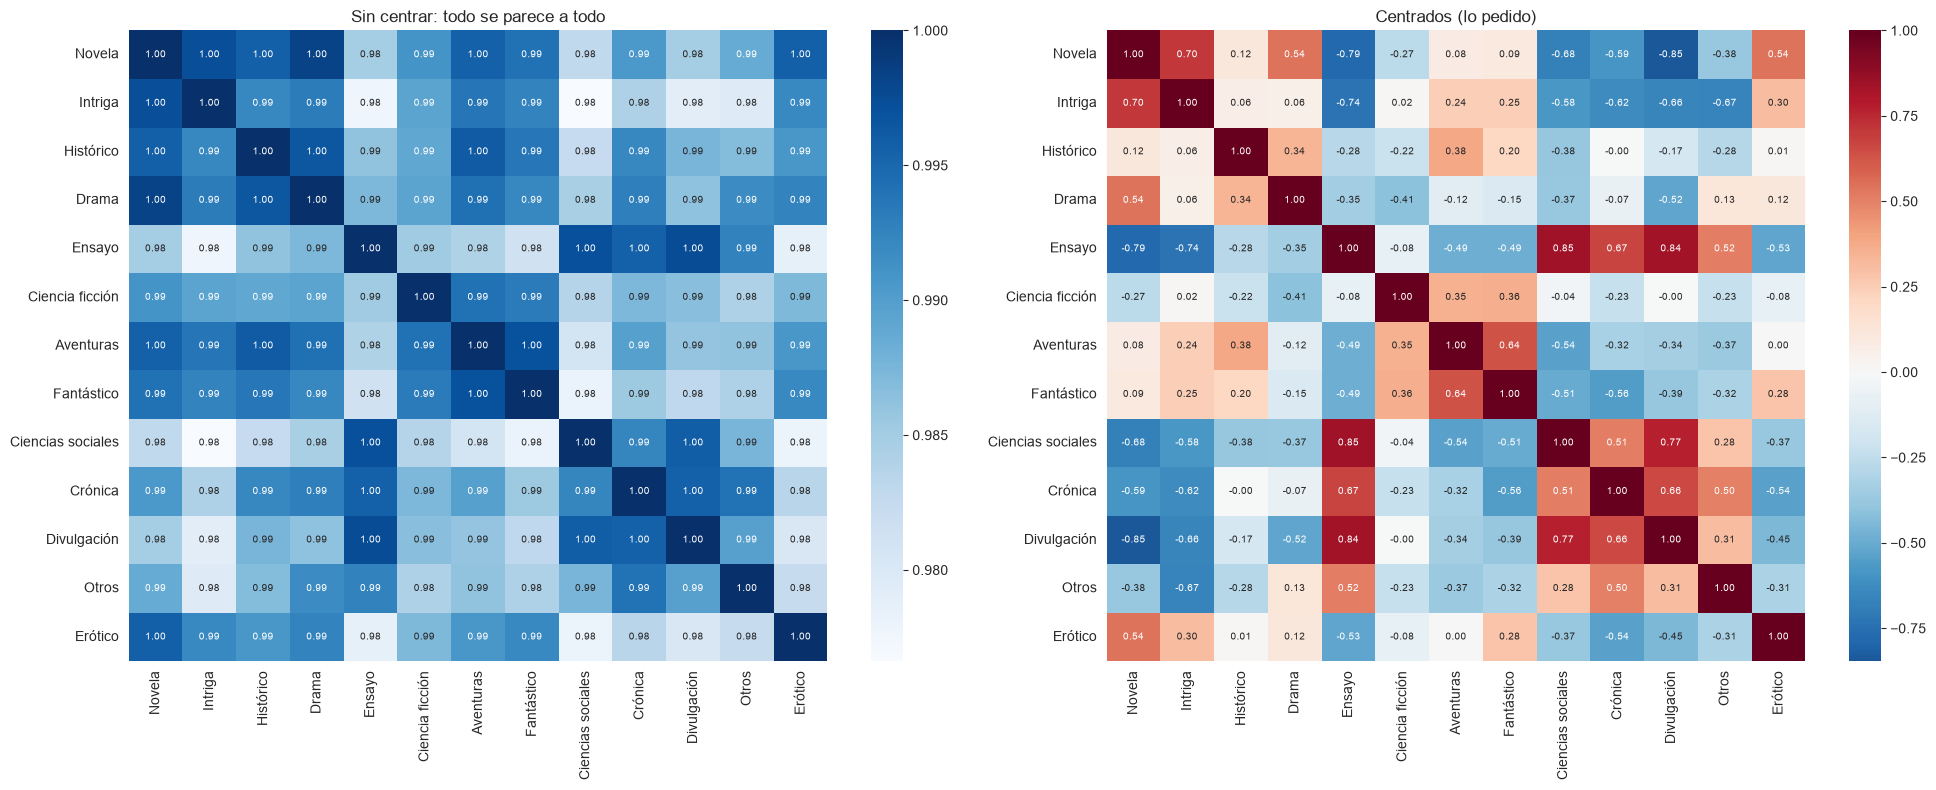

In [9]:
def similitud_generos(embeddings, df_libros, min_libros=1000):
    """
    TODO:
    1. Centrar embeddings: restar la media global (embeddings - embeddings.mean(axis=0))
    2. Filtrar géneros con >= min_libros
    3. Calcular centroide por género (promedio de embeddings centrados, normalizar)
    4. Calcular cosine_similarity entre centroides
    5. Graficar heatmap con sns.heatmap
    """
    # 1. Centrar: restar el vector promedio de todo el corpus
    centrados = embeddings - embeddings.mean(axis=0)

    # 2. Géneros con al menos min_libros
    conteo = df_libros["genero_principal"].value_counts()
    generos = conteo[conteo >= min_libros].index.tolist()

    # 3. Centroide (promedio) de cada género, normalizado a norma 1.
    #    Se calcula con y sin centrar para ver el efecto de centrar.
    def centroides(E):
        filas = []
        for g in generos:
            es_del_genero = (df_libros["genero_principal"] == g).to_numpy()
            filas.append(E[es_del_genero].mean(axis=0))
        C = np.array(filas)
        return C / np.linalg.norm(C, axis=1, keepdims=True)

    # 4. Similitud coseno entre centroides (matriz de géneros × géneros)
    sim_sin_centrar = cosine_similarity(centroides(embeddings))
    sim = cosine_similarity(centroides(centrados))

    # Promedio fuera de la diagonal (la diagonal es cada género consigo mismo = 1)
    fuera_diag = ~np.eye(len(generos), dtype=bool)
    print(f"{len(generos)} géneros con al menos {min_libros} libros")
    print(f"Similitud promedio entre géneros distintos, sin centrar: {sim_sin_centrar[fuera_diag].mean():.3f}")
    print(f"Similitud promedio entre géneros distintos, centrados:   {sim[fuera_diag].mean():.3f}")

    # Los pares más y menos parecidos (cada par una sola vez: j > i)
    pares = []
    for i in range(len(generos)):
        for j in range(i + 1, len(generos)):
            pares.append((sim[i, j], generos[i], generos[j]))
    pares.sort(reverse=True)
    print("\nPares más parecidos:")
    for s, a, b in pares[:5]:
        print(f"  {s:+.2f}  {a} — {b}")
    print("Pares más distintos:")
    for s, a, b in pares[-5:]:
        print(f"  {s:+.2f}  {a} — {b}")

    # 5. Heatmaps: a la izquierda sin centrar (el problema), a la derecha centrado (lo pedido)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    sns.heatmap(sim_sin_centrar, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=generos, yticklabels=generos, ax=axes[0], annot_kws={"size": 7})
    axes[0].set_title("Sin centrar: todo se parece a todo")
    sns.heatmap(sim, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                xticklabels=generos, yticklabels=generos, ax=axes[1], annot_kws={"size": 7})
    axes[1].set_title("Centrados (lo pedido)")
    plt.tight_layout()
    plt.show()


similitud_generos(embeddings, df_libros)

#### 📝 Interpretación — Ejercicio 3

- **Sin centrar** (izquierda), todos los pares de géneros tienen similitud de **~0,99** (promedio 0,989): no se distingue nada. Todos los embeddings comparten una componente grande, algo así como "esto es una sinopsis de libro en español". Al promediar miles de vectores, esa componente domina cada centroide.
- **Centrando** (derecha), es decir, restando el vector promedio del corpus, queda solo lo que cada género tiene **de distinto** al resto. El promedio entre géneros pasa a **−0,07** y aparece una estructura clara:
  - **La no ficción se parece entre sí:** Ensayo–Ciencias sociales (0,85), Ensayo–Divulgación (0,84), Ciencias sociales–Divulgación (0,77).
  - **Ficción y no ficción quedan en los extremos:** Novela–Divulgación (−0,85), Novela–Ensayo (−0,79), Intriga–Ensayo (−0,74).
  - **Dentro de la ficción hay parentescos esperables**, como Novela–Intriga (0,70) o Aventuras–Fantástico (0,64).
- **Idea para el examen:** el coseno mide ángulos respecto del origen. Si todos los vectores apuntan más o menos hacia el mismo lado (en la bibliografía se lo llama *anisotropía*), el coseno entre ellos siempre da alto. Centrar lleva el origen al centro de los datos, y recién ahí los ángulos reflejan diferencias.


---
# Parte 7 – Clustering con K-Means

¿Los embeddings agrupan naturalmente los libros por género?
Probemos con K-Means y visualicemos con PCA.

### Ejercicio 4 – Clustering sobre Embeddings

1. Filtrar los **top 5 géneros** más frecuentes
2. Aplicar K-Means (K=5) sobre los embeddings
3. Calcular **Silhouette Score**
4. Visualizar en 2D con PCA, coloreando por cluster

24,064 libros de ['Novela', 'Intriga', 'Histórico', 'Drama', 'Ensayo']


Silhouette score: 0.008
Adjusted Rand Index (clusters vs. géneros): 0.082

Composición de cada cluster (% de cada género):
género   Drama  Ensayo  Histórico  Intriga  Novela
cluster                                           
0         13.0    45.0       17.0      4.0    21.0
1          6.0     2.0        6.0     24.0    62.0
2          5.0     0.0        8.0     47.0    40.0
3         15.0     1.0       19.0     26.0    39.0
4         24.0     2.0       21.0     12.0    41.0


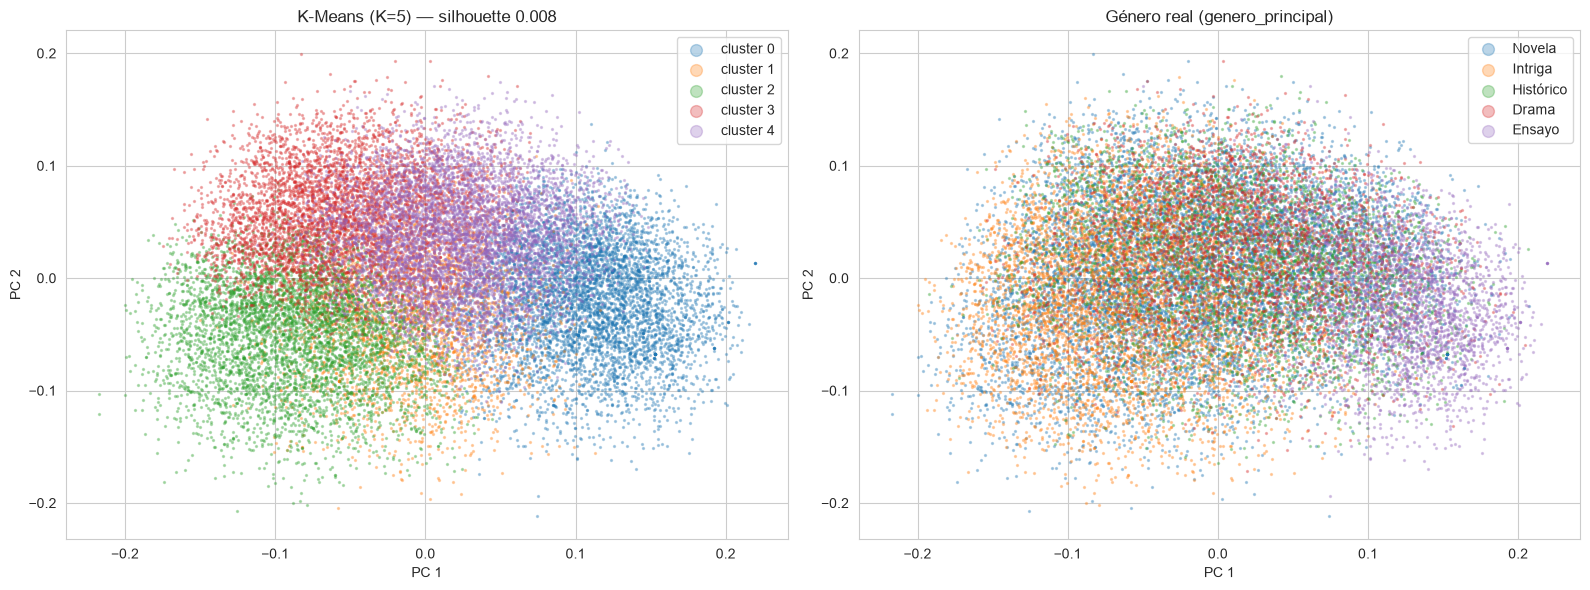

In [10]:
def clustering_embeddings(embeddings, df_libros, n_generos=5):
    """
    TODO:
    1. Filtrar top n_generos más frecuentes
    2. Aplicar KMeans(n_clusters=n_generos) sobre sus embeddings
    3. Calcular silhouette_score
    4. PCA a 2D y scatter plot coloreado por cluster
    """
    # 1. Libros de los n géneros más frecuentes
    top = df_libros["genero_principal"].value_counts().head(n_generos).index.tolist()
    es_top = df_libros["genero_principal"].isin(top).to_numpy()
    X = embeddings[es_top]
    generos = df_libros.loc[es_top, "genero_principal"].to_numpy()
    print(f"{len(X):,} libros de {top}")

    # 2. K-Means con tantos clusters como géneros
    kmeans = KMeans(n_clusters=n_generos, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X)

    # 3. Silhouette (de -1 a 1; cerca de 0 = clusters superpuestos). Compara distancias
    #    de todos contra todos, así que sobre ~24k libros se estima con una muestra de 5.000
    sil = silhouette_score(X, clusters, sample_size=5000, random_state=42)
    print(f"Silhouette score: {sil:.3f}")

    # Extra: ¿los clusters coinciden con los géneros? El ARI vale 1 si coinciden
    # exactamente y ~0 si la relación es la del azar
    print(f"Adjusted Rand Index (clusters vs. géneros): {adjusted_rand_score(generos, clusters):.3f}")
    print("\nComposición de cada cluster (% de cada género):")
    print((pd.crosstab(clusters, generos, rownames=["cluster"], colnames=["género"],
                       normalize="index") * 100).round(0).to_string())

    # 4. PCA a 2D. Dos paneles: color por cluster y color por género real
    X_2d = PCA(n_components=2, random_state=42).fit_transform(X)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for c in range(n_generos):
        m = clusters == c
        axes[0].scatter(X_2d[m, 0], X_2d[m, 1], s=2, alpha=0.3, label=f"cluster {c}")
    for g in top:
        m = generos == g
        axes[1].scatter(X_2d[m, 0], X_2d[m, 1], s=2, alpha=0.3, label=g)
    axes[0].set_title(f"K-Means (K={n_generos}) — silhouette {sil:.3f}")
    axes[1].set_title("Género real (genero_principal)")
    for ax in axes:
        ax.set(xlabel="PC 1", ylabel="PC 2")
        ax.legend(markerscale=6)
    plt.tight_layout()
    plt.show()


clustering_embeddings(embeddings, df_libros)

#### 📝 Interpretación — Ejercicio 4

- **Silhouette = 0,008**, prácticamente 0: los clusters están **superpuestos**, no hay grupos naturales bien separados. **ARI = 0,08**: los clusters casi no coinciden con los géneros.
- Aun así, K-Means **encuentra algo**, como muestra la tabla de composición:
  - un cluster de **no ficción**, con 45 % de Ensayo (en los demás, Ensayo casi no aparece), a la derecha del gráfico, igual que Ensayo en el panel de géneros;
  - uno cargado de **Intriga** (47 %), abajo a la izquierda;
  - el resto mezcla Novela, Drama e Histórico.
- **Por qué los clusters no coinciden con los géneros:**
  1. `genero_principal` es el primer género en orden alfabético, no el tema del libro.
  2. "Novela" es un formato, no un tema, y es cerca del 40 % de estos libros.
  3. Los temas reales (amor, guerra, crimen) cruzan los géneros.
  4. K-Means arma grupos compactos y de tamaño parecido, y acá los datos son una nube continua.


---
# Parte 8 – Visualización del Espacio Semántico

Reducimos 384 dimensiones a 2D para ver cómo se distribuyen los libros.

### Ejercicio 5 – Mapa Semántico con PCA

1. Filtrar los **top 8 géneros**
2. Aplicar PCA a 2D
3. Scatter plot coloreado por género con leyenda

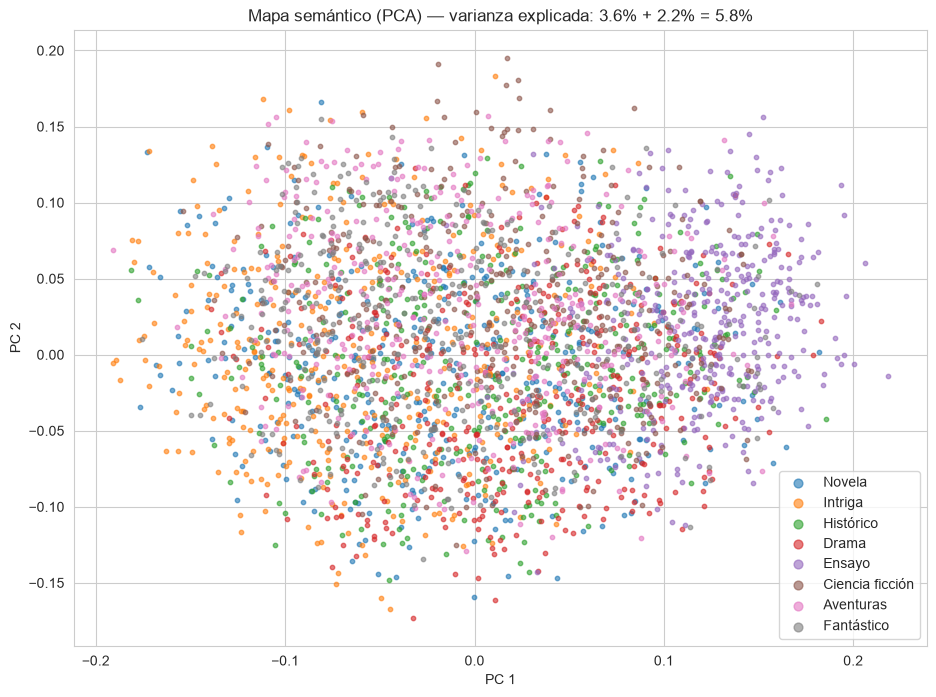

In [11]:
def mapa_semantico(embeddings, df_libros, n_generos=8):
    """
    TODO:
    1. Filtrar top n_generos
    2. PCA a 2D
    3. Scatter plot con colores por género y leyenda
    """
    # 1. Libros de los n géneros más frecuentes
    top = df_libros["genero_principal"].value_counts().head(n_generos).index.tolist()
    sub = df_libros[df_libros["genero_principal"].isin(top)]

    # 2. PCA a 2D, ajustado con todos esos libros. df_libros y embeddings están
    #    alineados fila a fila, así que sub.index sirve para tomar sus embeddings
    pca = PCA(n_components=2, random_state=42)
    pca.fit(embeddings[sub.index])

    # 3. Scatter. Con ~30k puntos se tapan entre sí: se grafican 400 por género, al azar
    muestra = sub.groupby("genero_principal", group_keys=False).sample(n=400, random_state=42)
    X_2d = pca.transform(embeddings[muestra.index])

    fig, ax = plt.subplots(figsize=(11, 8))
    for g in top:
        m = (muestra["genero_principal"] == g).to_numpy()
        ax.scatter(X_2d[m, 0], X_2d[m, 1], s=10, alpha=0.6, label=g)
    var = pca.explained_variance_ratio_
    ax.set(title=f"Mapa semántico (PCA) — varianza explicada: {var[0]:.1%} + {var[1]:.1%} = {var.sum():.1%}",
           xlabel="PC 1", ylabel="PC 2")
    ax.legend(markerscale=2)
    plt.show()


mapa_semantico(embeddings, df_libros)

#### 📝 Interpretación — Ejercicio 5

- **La PC 1 separa ficción de no ficción:** Ensayo se concentra a la derecha e Intriga a la izquierda. El resto (Novela, Drama, Histórico, Aventuras…) se superpone en el centro.
- Las 2 componentes explican el **5,8 %** de la varianza (3,6 % + 2,2 %). Es más que con TF-IDF, porque con 384 dimensiones en lugar de miles cada componente concentra más, pero sigue siendo poco: el mapa 2D es una sombra muy parcial del espacio.
- **PCA es lineal:** busca las direcciones de máxima varianza global. Si los géneros se diferencian en direcciones de poca varianza, en PCA no se ven (comparar con el t-SNE de abajo).


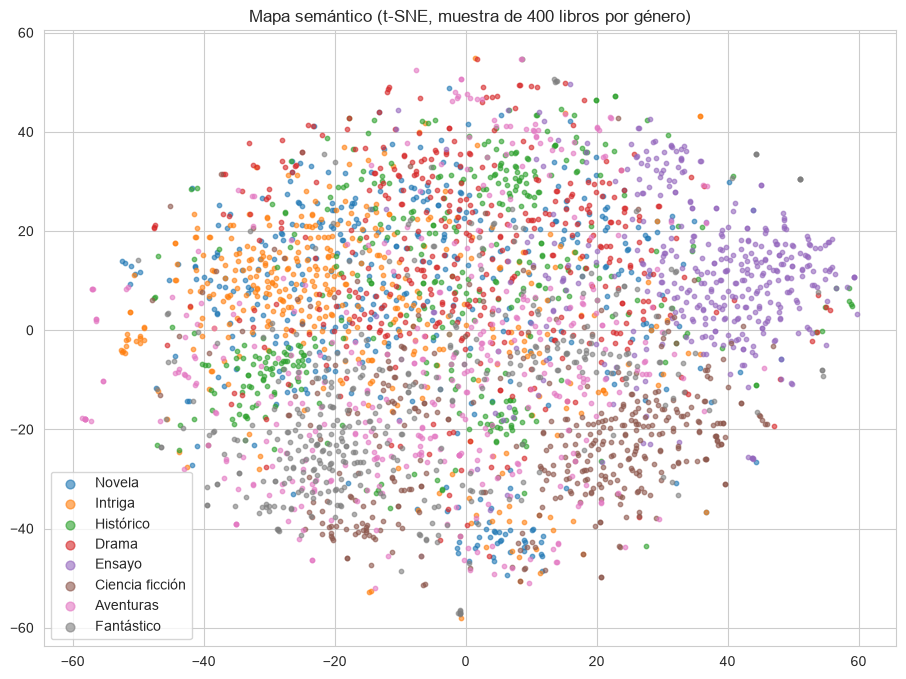

In [12]:
# ── Extra (no pedido): el mismo mapa con t-SNE ───────────────────────────────
# t-SNE (lo usa el apunte de la Unidad 2) es no lineal: conserva los vecindarios
# (quién está cerca de quién), no las distancias globales. Es lento, así que se aplica
# solo a la misma muestra de 400 libros por género.
top = df_libros["genero_principal"].value_counts().head(8).index.tolist()
sub = df_libros[df_libros["genero_principal"].isin(top)]
muestra = sub.groupby("genero_principal", group_keys=False).sample(n=400, random_state=42)

X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(embeddings[muestra.index])

fig, ax = plt.subplots(figsize=(11, 8))
for g in top:
    m = (muestra["genero_principal"] == g).to_numpy()
    ax.scatter(X_tsne[m, 0], X_tsne[m, 1], s=10, alpha=0.6, label=g)
ax.set(title="Mapa semántico (t-SNE, muestra de 400 libros por género)")
ax.legend(markerscale=2)
plt.show()


#### 📝 Interpretación — Extra: t-SNE

- Con **t-SNE** aparecen **zonas** bastante definidas que PCA no mostraba: Ensayo a la derecha, Intriga a la izquierda, Ciencia ficción abajo a la derecha y Fantástico abajo a la izquierda. Drama, Novela e Histórico siguen mezclados en el centro.
- **Por qué la diferencia:** t-SNE es no lineal y prioriza conservar **vecindarios** (quién está cerca de quién). PCA conserva la varianza global con una proyección lineal.
- **Cuidado al leerlo:** en t-SNE, el tamaño de los grupos y la distancia entre grupos lejanos **no significan nada**: solo vale la cercanía local. Además, el resultado cambia con `perplexity` y con la semilla.
- Que haya zonas por género confirma que los embeddings **sí** capturan el tema. El bajo puntaje del Ejercicio 4 se explica por las etiquetas y por cómo agrupa K-Means, no porque los embeddings no sirvan.


---
# Parte 9 – Comparativa: E5 vs TF-IDF

¿Qué tan distintos son los resultados de una búsqueda semántica (E5)
vs una búsqueda por palabras clave (TF-IDF)?

### Ejercicio 6 – E5 vs TF-IDF en Búsqueda

1. Vectorizar las sinopsis con `TfidfVectorizer`
2. Para 5 queries, buscar top-5 con ambos métodos
3. Contar cuántos resultados tienen en común (overlap)

In [13]:
def comparar_e5_tfidf(embeddings, df_libros, model):
    """
    TODO:
    1. Crear TfidfVectorizer y vectorizar sinopsis
    2. Para cada query: buscar top-5 con E5 y con TF-IDF
    3. Calcular overlap (cuántos libros en común de los 5)
    4. Imprimir resultados lado a lado
    """
    # 1. TF-IDF sobre las mismas sinopsis (palabras que aparecen en al menos 2 libros)
    tfidf = TfidfVectorizer(sublinear_tf=True, min_df=2)
    X_tfidf = tfidf.fit_transform(df_libros["sinopsis"])

    queries = [
        "historia de amor en tiempos de guerra",
        "aventuras de fantasía con dragones y magia",
        "divulgación científica sobre el universo",
        "un detective investiga un asesinato en un pueblo pequeño",
        "un relato de bucaneros en el Caribe",
    ]

    for query in queries:
        # 2. Top-5 con cada método (TF-IDF no usa el prefijo "query: " de E5)
        top_e5 = buscar_libros(query, embeddings, df_libros, model, n=5)
        scores_tfidf = cosine_similarity(tfidf.transform([query]), X_tfidf)[0]
        idx_tfidf = np.argsort(scores_tfidf)[::-1][:5]

        # 3. Overlap: libros (filas) que aparecen en los dos top-5
        comunes = set(top_e5.index) & set(idx_tfidf)

        # 4. Lado a lado
        print(f"\n«{query}»  →  libros en común: {len(comunes)}/5")
        tabla = pd.DataFrame({
            "E5": top_e5["titulo"].str[:40].values,
            "score E5": top_e5["score"].values,
            "TF-IDF": df_libros["titulo"].iloc[idx_tfidf].str[:40].values,
            "score TF-IDF": scores_tfidf[idx_tfidf].round(3),
        })
        print(tabla.to_string(index=False))


comparar_e5_tfidf(embeddings, df_libros, model)


«historia de amor en tiempos de guerra»  →  libros en común: 0/5
                               E5  score E5                        TF-IDF  score TF-IDF
             La mujer del Coronel     0.886                    Desertores         0.304
                        El auriga     0.880 La Mansión. Tiempos gloriosos         0.221
                   Tiempo que fue     0.879            Cuadernos Azabache         0.214
La guardiana de recuerdos de Kyiv     0.878         El color del silencio         0.211
                   Tinta y ceniza     0.878 El último viaje del Valentina         0.189



«aventuras de fantasía con dragones y magia»  →  libros en común: 0/5
                                    E5  score E5                                   TF-IDF  score TF-IDF
                    La pluma del grifo     0.885                               Más Allá 1         0.262
    Los mejores relatos de fantasía II     0.871      La venganza de la reina de dragones         0.229
                     El ojo del dragón     0.870                                   Favila         0.203
The Dragon Nindenn-Ka-Yh: Renacimiento     0.869                      La garra del dragón         0.196
              El libro de los dragones     0.869 Tiempo de dragones. La profecía imperfec         0.193



«divulgación científica sobre el universo»  →  libros en común: 1/5
                             E5  score E5                               TF-IDF  score TF-IDF
 Guía de la Tierra y el espacio     0.890                         Penumbria 24         0.235
El universo en una taza de café     0.881 El electrón es zurdo y otros ensayos         0.218
              Universos ocultos     0.877                      El río del Edén         0.202
        El universo en una caja     0.875                           Más Allá 1         0.199
       El planeta que no estaba     0.873       Guía de la Tierra y el espacio         0.197



«un detective investiga un asesinato en un pueblo pequeño»  →  libros en común: 0/5
                      E5  score E5                     TF-IDF  score TF-IDF
        Secretos ocultos     0.875     No uses anillo de boda         0.237
  La araña y la mariposa     0.874    El nacimiento de Cupido         0.226
Preludio para una muerte     0.873 Dos nombres para la muerte         0.201
   Una revelación brutal     0.872     El asesino de policías         0.198
           No digas nada     0.871         Cisne y murciélago         0.196



«un relato de bucaneros en el Caribe»  →  libros en común: 2/5
                         E5  score E5                     TF-IDF  score TF-IDF
                     Caribe     0.870    El libro de los piratas         0.279
La república de los piratas     0.868                     Caribe         0.207
       Cazadores de piratas     0.867 El príncipe de los piratas         0.198
  Ramage y los filibusteros     0.865      Los dueños del viento         0.175
              La última ola     0.865  Ramage y los filibusteros         0.165


#### 📝 Interpretación — Ejercicio 6

- **El overlap es casi nulo:** 0, 0, 1, 0 y 2 libros en común de 5. Los dos métodos responden a preguntas distintas.
- **TF-IDF busca palabras:**
  - Para "un detective investiga un asesinato en un pueblo pequeño", el primero es *No uses anillo de boda*: una sinopsis de apenas **25 palabras** que contiene "detective" e "investiga". Como es tan corta, después de normalizar, esas dos coincidencias pesan muchísimo.
  - Para "amor en tiempos de guerra", *Desertores* sale primero porque dice "guerra" dos veces, aunque no habla de amor.
  - También se cuelan revistas (*Más Allá*, *Penumbria*) con sinopsis cortas llenas de palabras clave.
- **E5 busca significado:** la sinopsis de *La mujer del Coronel* no dice "amor" sino "se enamoró", y es justamente una historia de amor en tiempos de guerra. *Secretos ocultos* trata de "un asesinato, un pueblo lleno de sospechosos".
- **El caso "bucaneros":** el enunciado del TP2 usa "piratas" contra "bucaneros" como ejemplo de dónde falla TF-IDF. Acá no falla tanto, porque *El libro de los piratas* sí contiene la palabra "bucaneros" y *Caribe* contiene "Caribe": coinciden 2 de 5. E5, en cambio, trae libros de piratas aunque no digan "bucaneros".
- **Los scores no son comparables entre métodos:** TF-IDF da 0,17–0,30 y E5 da 0,86–0,89, cada uno en su propia escala.


---
# Resumen

| Aspecto | TF-IDF | E5-small (Sentence Transformer) |
|---------|--------|---------------------------------|
| **Tipo de vector** | Sparse, alta dimensión | Denso, 384 dims |
| **Semántica** | Léxica (palabras exactas) | Contextual (significado) |
| **Multilingüe** | No | Sí (100+ idiomas) |
| **Velocidad** | Muy rápido | Moderado |
| **Mejor para** | Búsqueda por keywords | Búsqueda por significado |

### Flujo recomendado

1. **Vectorizar una vez** con el modelo E5
2. **Guardar en ZIP** para reutilizar
3. **Importar embeddings** sin necesidad del modelo
4. Solo cargar el modelo para **queries nuevas**